OTIMIZAÇÃO DO SISTEMA DE BOMBEAMENTO
Atende às regras DCP? True

Resolvendo problema (MILP)...


/usr/local/lib/python3.12/dist-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/usr/local/lib/python3.12/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Status do Solver: optimal_inaccurate

RESULTADOS OBTIDOS COM SUCESSO
Diâmetro escolhido : 150 mm
Volume diário      : 432.00 m³
CAPEX diário       : R$ 41.10
Custo energia      : R$ 23.54
Custo bombas       : R$ 640.00
Custo total        : R$ 704.64

Perfil de Operação de 24 Horas:
 Hora  Tarifa (R$/kWh)  Vazão (m³/s)  Bombas Ligadas  Potência (kW)  Altura Total (m)  Custo Energia (R$)
    0              0.5         0.015               1           5.89              30.0                2.94
    1              0.5         0.000               0           0.00              30.0                0.00
    2              0.5         0.015               1           5.89              30.0                2.94
    3              0.5         0.015               1           5.89              30.0                2.94
    4              0.5         0.015               1           5.89              30.0                2.94
    5              0.5         0.015               1           5.89              

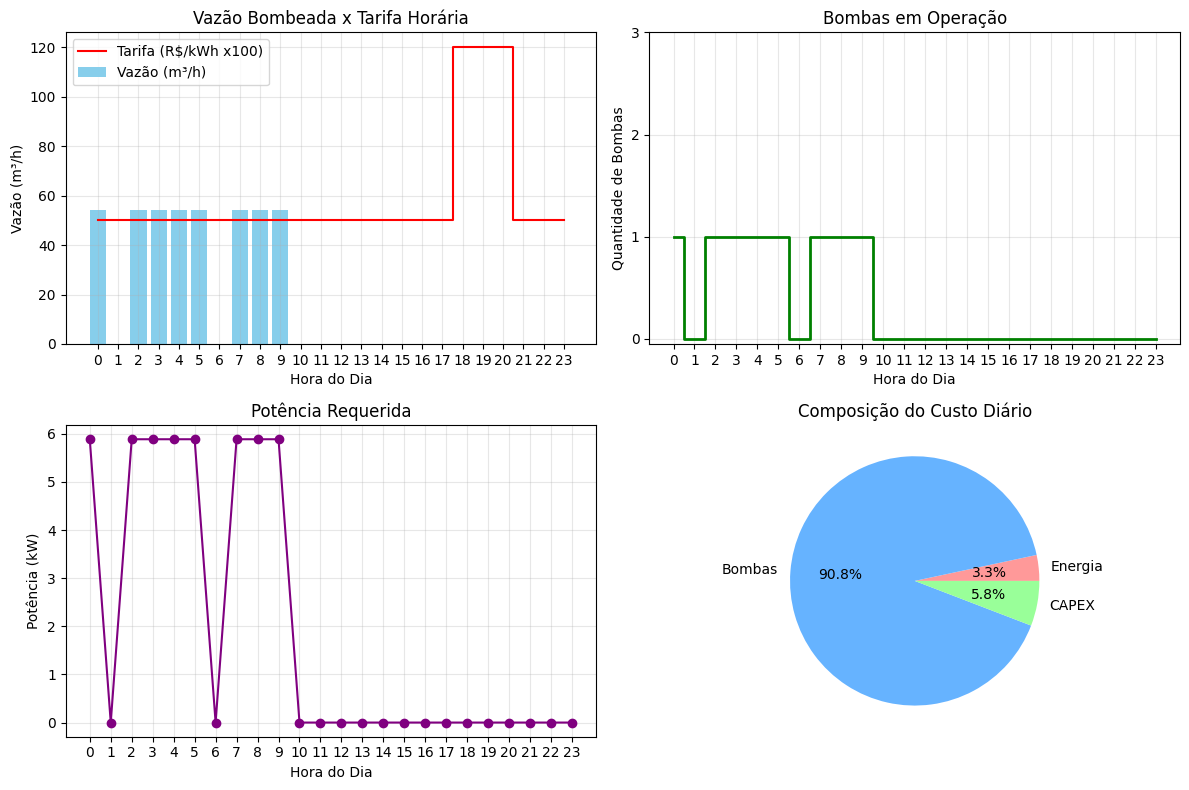

In [9]:
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# DADOS FÍSICOS
# ============================================================

rho = 1000.0                  # kg/m³
g = 9.81                      # m/s²
eta = 0.75                    # eficiência da bomba

HG = 30.0                     # altura geométrica (m)
L = 1000.0                    # comprimento da tubulação (m)

demanda_total = 400.0         # m³/dia

# ============================================================
# DIÂMETROS COMERCIAIS
# ============================================================

D_opcoes_mm = np.array([150, 200, 250, 300])
D_opcoes = D_opcoes_mm / 1000.0

Custo_capex_por_m = np.array([300, 450, 650, 900])

vida_util = 20
dias_ano = 365

n_D = len(D_opcoes)
kappa_D = (1.0 / (D_opcoes ** 5)) * 1e-4

# ============================================================
# BOMBAS
# ============================================================

N_max = 3
Q_bomba_nom = 0.015           # Vazão nominal por bomba (m³/s)
Custo_fixo_bomba = 80.0

# Modos de operação de bombas: k = 0, 1, 2, 3 bombas ligadas
modos_bombas = np.arange(N_max + 1)
n_k = len(modos_bombas)

# ============================================================
# PRÉ-CÁLCULO DE PARÂMETROS HIDRÁULICOS (I, K)
# ============================================================

Q_modo = modos_bombas * Q_bomba_nom

Q_mat = np.zeros((n_D, n_k))
hf_mat = np.zeros((n_D, n_k))
P_mat = np.zeros((n_D, n_k))

for i in range(n_D):
    for k in range(n_k):
        q = Q_modo[k]
        Q_mat[i, k] = q

        # Perda de carga (m)
        hf = kappa_D[i] * (q ** 2)
        hf_mat[i, k] = hf

        # Altura manométrica total (m)
        H_tot = HG + hf

        # Potência consumida (kW)
        if q > 0:
            P_mat[i, k] = (rho * g * q * H_tot) / (eta * 1000.0)
        else:
            P_mat[i, k] = 0.0

# ============================================================
# TARIFA HORÁRIA
# ============================================================

tarifa = np.array([0.50] * 18 + [1.20] * 3 + [0.50] * 3)
horas = np.arange(24)

# ============================================================
# VARIÁVEIS DE DECISÃO
# ============================================================

# z_D[i] = 1 se o diâmetro i for o escolhido globalmente
z_D = cp.Variable(n_D, boolean=True, name="z_D")

# x[h, i, k] = 1 se na hora h for usado o diâmetro i com k bombas ligadas
x = cp.Variable((24, n_D, n_k), boolean=True, name="x")

# ============================================================
# RESTRIÇÕES
# ============================================================

restricoes = []

# 1. Escolha de um único diâmetro comercial
restricoes.append(cp.sum(z_D) == 1)

# 2. Em cada hora h, exatamente um modo de operação (i, k) deve estar ativo
for h in range(24):
    restricoes.append(cp.sum(x[h, :, :]) == 1)

# 3. Consistência: O modo (i, k) só pode ser ativado se o diâmetro i for o escolhido
for h in range(24):
    for i in range(n_D):
        restricoes.append(cp.sum(x[h, i, :]) <= z_D[i])

# 4. Atendimento da demanda diária de água
volume_diario_expr = 0
for h in range(24):
    for i in range(n_D):
        for k in range(n_k):
            volume_diario_expr += x[h, i, k] * Q_mat[i, k] * 3600

restricoes.append(volume_diario_expr >= demanda_total)

# ============================================================
# FUNÇÃO OBJETIVO
# ============================================================

custo_operacional = 0

for h in range(24):
    for i in range(n_D):
        for k in range(n_k):
            custo_energia_hik = P_mat[i, k] * tarifa[h]
            custo_bombas_hik = k * Custo_fixo_bomba

            custo_operacional += x[h, i, k] * (custo_energia_hik + custo_bombas_hik)

# CAPEX diário
Custo_capex_total = L * (Custo_capex_por_m @ z_D)
Custo_capex_diario = Custo_capex_total / (vida_util * dias_ano)

Custo_total = custo_operacional + Custo_capex_diario

# ============================================================
# RESOLUÇÃO DO PROBLEMA
# ============================================================

problema = cp.Problem(cp.Minimize(Custo_total), restricoes)

print("=" * 70)
print("OTIMIZAÇÃO DO SISTEMA DE BOMBEAMENTO")
print("=" * 70)
print(f"Atende às regras DCP? {problema.is_dcp()}")

print("\nResolvendo problema (MILP)...")
problema.solve(solver=cp.ECOS_BB, verbose=False)

print("Status do Solver:", problema.status)

if problema.status not in ["optimal", "optimal_inaccurate"]:
    raise RuntimeError("O erro de solução persiste.")

# ============================================================
# PROCESSAMENTO DOS RESULTADOS
# ============================================================

z_val = np.round(z_D.value)
indice_diametro = int(np.argmax(z_val))
diametro_escolhido_mm = D_opcoes_mm[indice_diametro]

capex_total = L * Custo_capex_por_m[indice_diametro]
capex_diario = capex_total / (vida_util * dias_ano)

x_val = np.round(x.value)

Q_resultado = np.zeros(24)
bombas_resultado = np.zeros(24, dtype=int)
potencia_resultado = np.zeros(24)
altura_resultado = np.zeros(24)
energia_resultado = np.zeros(24)

for h in range(24):
    for k in range(n_k):
        if x_val[h, indice_diametro, k] > 0.5:
            Q_resultado[h] = Q_mat[indice_diametro, k]
            bombas_resultado[h] = k
            potencia_resultado[h] = P_mat[indice_diametro, k]
            altura_resultado[h] = HG + hf_mat[indice_diametro, k]
            energia_resultado[h] = P_mat[indice_diametro, k] * tarifa[h]

volume_total = np.sum(Q_resultado) * 3600
custo_energia = np.sum(energia_resultado)
custo_bombas = np.sum(bombas_resultado * Custo_fixo_bomba)

print("\n" + "=" * 70)
print("RESULTADOS OBTIDOS COM SUCESSO")
print("=" * 70)
print(f"Diâmetro escolhido : {diametro_escolhido_mm:.0f} mm")
print(f"Volume diário      : {volume_total:.2f} m³")
print(f"CAPEX diário       : R$ {capex_diario:.2f}")
print(f"Custo energia      : R$ {custo_energia:.2f}")
print(f"Custo bombas       : R$ {custo_bombas:.2f}")
print(f"Custo total        : R$ {problema.value:.2f}")

# ============================================================
# TABELA COMPLETA DAS 24 HORAS
# ============================================================

df = pd.DataFrame({
    "Hora": horas,
    "Tarifa (R$/kWh)": tarifa,
    "Vazão (m³/s)": np.round(Q_resultado, 4),
    "Bombas Ligadas": bombas_resultado,
    "Potência (kW)": np.round(potencia_resultado, 2),
    "Altura Total (m)": np.round(altura_resultado, 2),
    "Custo Energia (R$)": np.round(energia_resultado, 2)
})

print("\nPerfil de Operação de 24 Horas:")
# Exibe todas as 24 linhas sem filtrar
print(df.to_string(index=False))

# ============================================================
# GRÁFICOS DE 24 HORAS
# ============================================================

plt.figure(figsize=(12, 8))

# 1. Vazão x Tarifa
plt.subplot(2, 2, 1)
plt.bar(horas, Q_resultado * 3600, color='skyblue', label='Vazão (m³/h)')
plt.step(horas, tarifa * 100, color='red', where='mid', label='Tarifa (R$/kWh x100)')
plt.xticks(horas)
plt.xlabel("Hora do Dia")
plt.ylabel("Vazão (m³/h)")
plt.title("Vazão Bombeada x Tarifa Horária")
plt.grid(True, alpha=0.3)
plt.legend()

# 2. Bombas Ligadas
plt.subplot(2, 2, 2)
plt.step(horas, bombas_resultado, where='mid', color='green', linewidth=2)
plt.yticks(range(N_max + 1))
plt.xticks(horas)
plt.xlabel("Hora do Dia")
plt.ylabel("Quantidade de Bombas")
plt.title("Bombas em Operação")
plt.grid(True, alpha=0.3)

# 3. Potência Consumida
plt.subplot(2, 2, 3)
plt.plot(horas, potencia_resultado, marker='o', color='purple')
plt.xticks(horas)
plt.xlabel("Hora do Dia")
plt.ylabel("Potência (kW)")
plt.title("Potência Requerida")
plt.grid(True, alpha=0.3)

# 4. Composição dos Custos Diários
plt.subplot(2, 2, 4)
plt.pie([custo_energia, custo_bombas, capex_diario],
        labels=['Energia', 'Bombas', 'CAPEX'],
        autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("Composição do Custo Diário")

plt.tight_layout()
plt.show()